# Department Co-purchases with Produce

The merchandising analytics team wants to understand how frequently different product departments are purchased together with Produce.

The analysis uses the prior purchase history from:

- `order_products__prior.csv`
- `products.csv`
- `departments.csv`

Orders containing at least one Produce product are first identified. All product purchases within those orders are then grouped by department, and the resulting purchase counts are used to compare departments purchased alongside Produce.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


DATA_DIR = "../../data/shop"


order_products = pd.read_csv(
    f"{DATA_DIR}/order_products__prior.csv",
    usecols=["order_id", "product_id"],
)

products = pd.read_csv(
    f"{DATA_DIR}/products.csv",
    usecols=["product_id", "department_id"],
)

departments = pd.read_csv(
    f"{DATA_DIR}/departments.csv",
)


# Map products to departments.
order_products = order_products.merge(
    products,
    on="product_id",
    how="left",
)


# Identify Produce orders.
produce_id = departments.loc[
    departments["department"].eq("produce"),
    "department_id",
].iloc[0]

produce_orders = order_products.loc[
    order_products["department_id"].eq(produce_id),
    "order_id",
].unique()


# Count purchase records from other departments
# within Produce orders.
produce_items = order_products[
    order_products["order_id"].isin(produce_orders)
    & order_products["department_id"].ne(produce_id)
]

copurchase_counts = (
    produce_items["department_id"]
    .value_counts()
    .rename_axis("department_id")
    .reset_index(name="copurchase_count")
    .merge(
        departments,
        on="department_id",
        how="left",
    )
    [["department", "copurchase_count"]]
)


print("Top departments purchased with Produce:")
print(
    copurchase_counts
    .head(15)
    .to_string(index=False)
)

Files loaded: 6.2s
Departments mapped: 7.1s
Produce orders found: 2,409,320; elapsed: 7.4s

Top departments purchased with Produce:
     department  copurchase_count
     dairy eggs           4604171
         snacks           2270136
      beverages           1956409
         frozen           1822481
         pantry           1574727
         bakery            990718
   canned goods            948397
           deli            911674
dry goods pasta            757995
   meat seafood            625998
      breakfast            569331
      household            499415
         babies            359051
  personal care            307563
  international            234907

Total elapsed: 7.9s


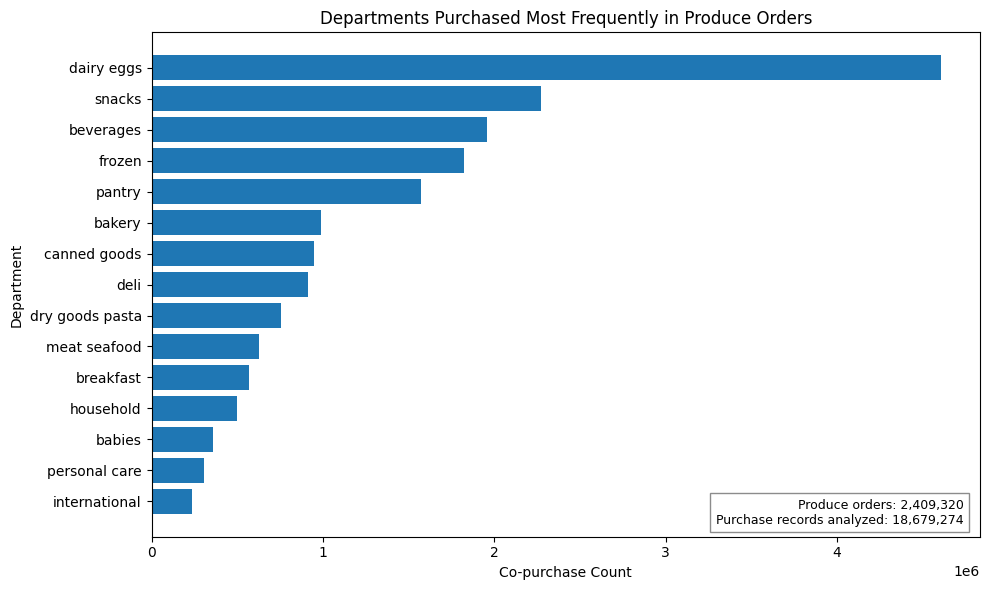

In [ ]:
top_departments = (
    copurchase_counts
    .head(15)
    .sort_values(
        "copurchase_count",
        ascending=True,
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    top_departments["department"],
    top_departments["copurchase_count"],
)

ax.set_title(
    "Departments Purchased Most Frequently "
    "in Produce Orders"
)

ax.set_xlabel(
    "Co-purchase Count"
)

ax.set_ylabel(
    "Department"
)


# Subtle hint about the analytical unit.
ax.text(
    0.98,
    0.02,
    (
        f"Produce orders: {len(produce_orders):,}\n"
        f"Purchase records analyzed: {len(produce_items):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)


plt.tight_layout()
plt.show()

## Conclusion

The chart shows which departments account for the largest numbers of purchases within orders containing Produce.

Departments with higher counts are more frequently represented among the purchased items in Produce orders and may be useful candidates for cross-merchandising or joint promotions with Produce.